# A* Search Algorithm

## 📚 Learning Objectives

By completing this notebook, you will:
- Implement A* with a heuristic
- Compare A* with BFS/DFS on informed search

## 🔗 Where this fits

**Builds on:** Unit 1, lessons 06-07 (BFS and DFS) — uninformed search; A* adds a heuristic to make the frontier informed.

**Used later in:** Course 02 (AIAT 112) — Unit 4, where "follow the estimate downhill" reappears as optimization.

---


## 🎯 A* was written to move a robot across a room

A* is not a textbook abstraction: it was built for a specific machine. Between
1966 and 1972, SRI International in California ran **Shakey**, the first mobile
robot that could reason about its own actions — perceive a room, plan a sequence
of moves, and carry them out. Shakey needed to get from one place to another
without exploring every route, and the algorithm Peter Hart, Nils Nilsson and
Bertram Raphael wrote for it was published in 1968 as A* (reference 1 below).
Nearly sixty years later the same procedure is in your phone's route planner and
in the pathfinding of most games you have played.

The insight is one line long. BFS and DFS know only the graph. A* is allowed one
extra thing — an **estimate of how far the goal still is** — and it spends its
search budget on the nodes that estimate says are promising.

### What goes wrong without a heuristic

Notebook 06 showed it: BFS reached F only after expanding **every** node at
distance 1 and then every node at distance 2 — including D, a dead end pointing
away from the goal. Uninformed search cannot tell "toward the goal" from "away
from it", so on a map it explores a circle around the start. At city scale that
circle is millions of intersections. The heuristic is what turns the circle into
a beam.


# A* Search Algorithm

## 📚 Learning Objectives

This notebook demonstrates key concepts through hands-on examples.

By completing this notebook, you will:
- Understand the core concepts
- See practical implementations
- Be ready for exercises

**Common Student Questions:**
- **Q: Why use A* instead of BFS or DFS?**
  - Answer: A* is smarter - uses heuristic to guide search toward goal
  - BFS/DFS: Blind search (explore randomly)
  - A*: Informed search (explore toward goal) → faster, finds optimal path
  - Example: GPS uses A* (knows direction to destination) vs BFS (explores all directions)
- **Q: What is a heuristic function?**
  - Answer: Heuristic = estimate of distance to goal (e.g., straight-line distance)
  - Helps A* prioritize nodes closer to goal
  - Example: Manhattan distance (sum of x and y differences)
  - Must be admissible (never overestimate) for A* to find optimal path
- **Q: Why does A* find optimal path?**
  - Answer: A* uses f(n) = g(n) + h(n) where:
  - g(n) = actual cost from start to n
  - h(n) = estimated cost from n to goal (heuristic)
  - If heuristic is admissible (never overestimates), A* guarantees optimal path
- **Q: When should I use A* vs BFS/DFS?**
  - Answer: A* = optimal path, faster than BFS (uses heuristic)
  - BFS = shortest path in unweighted graphs, simpler
  - DFS = any path, less memory
  - Use A* when: Weighted graph, need optimal path, have good heuristic
  - Use BFS when: Unweighted graph, need shortest path, simple is enough
  - Use DFS when: Need any path, memory limited

## 🔗 Prerequisites

- ✅ Python 3.8+ installed
- ✅ Required libraries (see `requirements.txt`)
- ✅ Basic Python knowledge

---

## Code Example

Run the code below to see the demonstration:

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

Example 3: A* Algorithm

Testing A* Algorithm

Searching for optimal path from A to F...
  Visiting: A, Path: A, Cost: 0
  Visiting: B, Path: A -> B, Cost: 1
  Visiting: C, Path: A -> C, Cost: 1
  Visiting: F, Path: A -> C -> F, Cost: 2

✓ Optimal path found! Path: A -> C -> F, Total cost: 2

Final Result: ['A', 'C', 'F']

Example completed successfully!


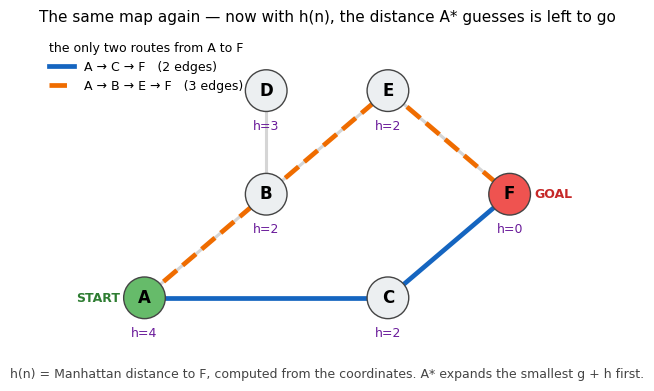


Routes from A to F found by enumeration: A → C → F (2 edges) | A → B → E → F (3 edges)


In [1]:
"""
Unit 1 - Example 08: A* Algorithm

This example demonstrates:
1. A* algorithm implementation
2. Heuristic functions
3. Optimal pathfinding
"""

import heapq

print("=" * 60)
print("Example 3: A* Algorithm")
print("=" * 60)

# Graph with coordinates for heuristic calculation
graph = {
    'A': {'neighbors': ['B', 'C'], 'coords': (0, 0)},
    'B': {'neighbors': ['A', 'D', 'E'], 'coords': (1, 1)},
    'C': {'neighbors': ['A', 'F'], 'coords': (2, 0)},
    'D': {'neighbors': ['B'], 'coords': (1, 2)},
    'E': {'neighbors': ['B', 'F'], 'coords': (2, 2)},
    'F': {'neighbors': ['C', 'E'], 'coords': (3, 1)}
}

def heuristic(node1, node2):
    """
    Manhattan distance heuristic.
    """
    x1, y1 = graph[node1]['coords']
    x2, y2 = graph[node2]['coords']
    return abs(x1 - x2) + abs(y1 - y2)

def astar(graph, start, goal):
    """
    A* pathfinding algorithm.
    """
    # Priority queue: (f_score, g_score, node, path)
    open_set = [(0, 0, start, [start])]
    visited = set()
    
    print(f"\nSearching for optimal path from {start} to {goal}...")
    
    while open_set:
        f_score, g_score, current, path = heapq.heappop(open_set)
        
        if current in visited:
            continue
        
        visited.add(current)
        
        print(f"  Visiting: {current}, Path: {' -> '.join(path)}, Cost: {g_score}")
        
        if current == goal:
            print(f"\n✓ Optimal path found! Path: {' -> '.join(path)}, Total cost: {g_score}")
            return path
        
        # Explore neighbors
        for neighbor in graph[current]['neighbors']:
            if neighbor in visited:
                continue
            
            # Calculate costs
            new_g_score = g_score + 1  # Assuming edge cost of 1
            h_score = heuristic(neighbor, goal)
            f_score = new_g_score + h_score
            
            heapq.heappush(open_set, (f_score, new_g_score, neighbor, path + [neighbor]))
    
    print(f"\n✗ No path found from {start} to {goal}")
    return None

# Test A*
print("\n" + "=" * 60)
print("Testing A* Algorithm")
print("=" * 60)

path = astar(graph, 'A', 'F')
print(f"\nFinal Result: {path}")

print("\n" + "=" * 60)
print("Example completed successfully!")
print("=" * 60)

# ── The map, drawn ONCE, with the only two routes from A to F ────────────────
# WHAT: one picture of the same six-node graph the trace above walked, on the FIXED
#       coordinates notebooks 06, 07 and 08 all share, with every A→F route traced.
# WHY : the printed trace is a list of node names. The question the three search
#       notebooks differ on is "which route comes back?" — and you cannot ask that
#       until you can see that there are exactly two of them.
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.lines import Line2D

POS = {'A': (0, 0), 'B': (1, 1), 'C': (2, 0), 'D': (1, 2), 'E': (2, 2), 'F': (3, 1)}
G_map = nx.Graph()
for _node, _data in graph.items():
    for _nbr in _data['neighbors']:
        G_map.add_edge(_node, _nbr)

# Enumerated, not guessed: ask networkx for every simple path and sort by length.
routes = sorted(nx.all_simple_paths(G_map, 'A', 'F'), key=len)

fig_map, ax_map = plt.subplots(figsize=(7.0, 4.0))
nx.draw_networkx_edges(G_map, POS, ax=ax_map, edge_color='#d5d5d5', width=2.2)
handles = []
for _route, (_col, _style) in zip(routes, [('#1565c0', 'solid'), ('#ef6c00', 'dashed')]):
    nx.draw_networkx_edges(G_map, POS, edgelist=list(zip(_route, _route[1:])), ax=ax_map,
                           edge_color=_col, width=3.4, style=_style)
    handles.append(Line2D([], [], color=_col, lw=3.4, linestyle=_style,
                          label=f"{' → '.join(_route)}   ({len(_route) - 1} edges)"))
_colours = ['#66bb6a' if n == 'A' else '#ef5350' if n == 'F' else '#eceff1'
            for n in G_map.nodes()]
nx.draw_networkx_nodes(G_map, POS, ax=ax_map, node_color=_colours,
                       edgecolors='#444444', node_size=900)
nx.draw_networkx_labels(G_map, POS, ax=ax_map, font_size=12, font_weight='bold')
ax_map.text(POS['A'][0] - 0.20, POS['A'][1], "START", fontsize=9, color='#2e7d32',
            va='center', ha='right', fontweight='bold')
ax_map.text(POS['F'][0] + 0.20, POS['F'][1], "GOAL", fontsize=9, color='#c62828',
            va='center', ha='left', fontweight='bold')
for _n, (_x, _y) in POS.items():                 # the heuristic, printed where it applies
    _h = abs(_x - POS['F'][0]) + abs(_y - POS['F'][1])
    ax_map.text(_x, _y - 0.28, f"h={_h}", fontsize=9, color='#6a1b9a',
                ha='center', va='top')
ax_map.legend(handles=handles, loc='upper left', fontsize=9, frameon=False,
              title="the only two routes from A to F", title_fontsize=9)
ax_map.set_title("The same map again — now with h(n), the distance A* guesses is left to go", fontsize=11)
ax_map.text(0.5, -0.06, "h(n) = Manhattan distance to F, computed from the coordinates. A* expands the smallest g + h first.", transform=ax_map.transAxes, ha='center',
            fontsize=9, color='#444444')
ax_map.set_axis_off()
ax_map.margins(0.22)
fig_map.tight_layout()
plt.show()

print(f"\nRoutes from A to F found by enumeration: "
      f"{' | '.join(' → '.join(r) + f' ({len(r) - 1} edges)' for r in routes)}")


### 👁️ Read the map

**Same six nodes, same coordinates, same two routes as notebooks 06 and 07** — and
one new thing: the purple `h=` number under every node.

`h(n)` is the Manhattan distance from that node to `F`, computed straight from the
coordinates in the `graph` dictionary. Read them off: `h(A)=4`, `h(B)=2`, `h(C)=2`,
`h(D)=3`, `h(E)=2`, `h(F)=0`. Nothing here was measured by searching — these are
**guesses made before any search happens**, and they are what BFS and DFS did not have.

Look at `D`, the dead end. Its `h=3` is a worse guess than either of the nodes A*
could take instead (`C` and `E` both show `h=2`), and `D` sits two edges from `A`, so
its `f = g + h` comes out at **5** — the largest number in the open set at every step
of the storyboard below. `F` reaches `f=2`. A* pops `F` long before it would ever
reach `D`, so **`D` is never expanded at all**: BFS spent an expansion there, A* spends
none. The rule is only `f = g + h`, expand smallest `f` first — and the purple numbers
on this map are the `h` half of it, known before a single edge is followed.


Heuristic h(n) = Manhattan distance to F: A:4  B:2  C:2  D:3  E:2  F:0


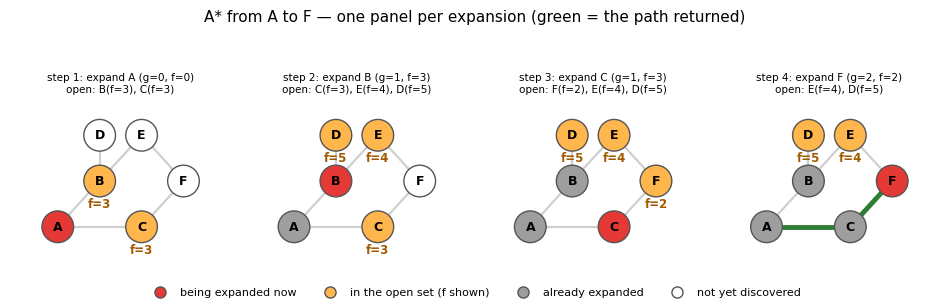


step  expand   g  f  open set after (cheapest f first)  path so far
   1    A      0  0  [B(f=3), C(f=3)]                   A
   2    B      1  3  [C(f=3), E(f=4), D(f=5)]           A -> B
   3    C      1  3  [F(f=2), E(f=4), D(f=5)]           A -> C
   4    F      2  2  [E(f=4), D(f=5)]                   A -> C -> F

Expanded 4 nodes; D and E were discovered but never expanded.


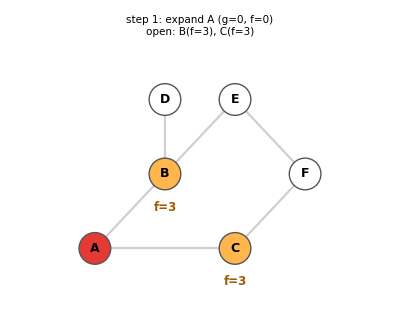


Animated GIF above: 4 frames, 22 KB


In [2]:
# ── Storyboard: watch A* follow the heuristic, one expansion at a time ────────
# WHAT: replay the EXACT A* run printed above (A -> F), recording the open set with each
#       node's f = g + h at every expansion, then draw one panel per step plus a GIF.
# WHY:  BFS and DFS chose the next node by *arrival order*. A* chooses by a NUMBER, and
#       the number is printed on every node here — so you can see the heuristic steer.
import io

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from matplotlib.lines import Line2D

# These are the graph's own coordinates — the same positions used in notebooks 06 and 07,
# and the very numbers the Manhattan heuristic is computed from.
POS = {node: data['coords'] for node, data in graph.items()}

G = nx.Graph()
for node, data in graph.items():
    for neighbour in data['neighbors']:
        G.add_edge(node, neighbour)

# h(n) = Manhattan distance from n to the goal — the "guess" that makes A* different.
H = {node: heuristic(node, 'F') for node in graph}
print("Heuristic h(n) = Manhattan distance to F:",
      "  ".join(f"{n}:{h}" for n, h in H.items()))


def astar_trace(gr, start, goal):
    """Same algorithm as astar() above — it RECORDS state instead of printing it."""
    import heapq
    open_set = [(0, 0, start, [start])]
    visited = set()
    steps = []
    while open_set:
        f_score, g_score, current, path = heapq.heappop(open_set)
        if current in visited:
            continue
        visited.add(current)
        if current != goal:
            for neighbour in gr[current]['neighbors']:
                if neighbour in visited:
                    continue
                new_g = g_score + 1
                heapq.heappush(open_set, (new_g + heuristic(neighbour, goal),
                                          new_g, neighbour, path + [neighbour]))
        # what is waiting in the open set right now, cheapest f first
        waiting = sorted({(n, ff) for ff, _, n, _ in open_set if n not in visited},
                         key=lambda t: (t[1], t[0]))
        steps.append({'current': current, 'g': g_score, 'f': f_score,
                      'path': path, 'open': waiting, 'visited': set(visited)})
        if current == goal:
            break
    return steps


steps = astar_trace(graph, 'A', 'F')

# Honesty check: the storyboard must show the same run the cell above printed.
assert [s['current'] for s in steps] == ['A', 'B', 'C', 'F'], "visit order changed"
assert steps[-1]['path'] == path, "path changed"


def draw_step(ax, s, k, done):
    """Colour nodes by role, and label each node with its f = g + h when known."""
    expanded = [st['current'] for st in steps[:k]]
    open_f = dict(s['open'])
    colours = []
    for n in G.nodes():
        if n == s['current']:
            colours.append('#e53935')          # red   = being expanded right now
        elif n in expanded:
            colours.append('#9e9e9e')          # grey  = already expanded
        elif n in open_f:
            colours.append('#ffb74d')          # amber = in the open set, waiting
        else:
            colours.append('white')            # white = not discovered yet
    nx.draw_networkx_edges(G, POS, ax=ax, edge_color='#cfcfcf', width=1.6)
    nx.draw_networkx_nodes(G, POS, ax=ax, node_color=colours,
                           edgecolors='#555555', node_size=520)
    nx.draw_networkx_labels(G, POS, ax=ax, font_size=9, font_weight='bold')
    # print f-scores just under the amber nodes: this is what A* compares
    for n, f_val in open_f.items():
        x, y = POS[n]
        ax.text(x, y - 0.36, f"f={f_val}", ha='center', va='top', fontsize=8.5,
                color='#a25a00', fontweight='bold')
    if done:                                    # last panel: the path A* returned
        p = s['path']
        nx.draw_networkx_edges(G, POS, edgelist=list(zip(p, p[1:])), ax=ax,
                               edge_color='#2e7d32', width=3.5)
    open_txt = ', '.join(f"{n}(f={f_val})" for n, f_val in s['open']) or '—'
    ax.set_title(f"step {k + 1}: expand {s['current']} (g={s['g']}, f={s['f']})\nopen: {open_txt}",
                 fontsize=7.5)
    ax.set_axis_off()
    ax.margins(0.30)


n_steps = len(steps)
fig, axes = plt.subplots(1, n_steps, figsize=(2.4 * n_steps, 3.0))
for k, (ax, s) in enumerate(zip(axes, steps)):
    draw_step(ax, s, k, done=(k == n_steps - 1))
legend = [Line2D([], [], marker='o', linestyle='', markersize=8, markerfacecolor=c,
                 markeredgecolor='#555', label=l)
          for c, l in [('#e53935', 'being expanded now'), ('#ffb74d', 'in the open set (f shown)'),
                       ('#9e9e9e', 'already expanded'), ('white', 'not yet discovered')]]
fig.legend(handles=legend, loc='lower center', ncol=4, frameon=False, fontsize=8)
fig.suptitle('A* from A to F — one panel per expansion (green = the path returned)', fontsize=11)
fig.tight_layout(rect=[0, 0.09, 1, 0.92])
plt.show()

# The same storyboard as a table you can read out loud in class.
print(f"\n{'step':>4}  {'expand':^6}  {'g':>2} {'f':>2}  {'open set after (cheapest f first)':<34} path so far")
for k, s in enumerate(steps, 1):
    open_txt = '[' + ', '.join(f"{n}(f={f_val})" for n, f_val in s['open']) + ']'
    print(f"{k:>4}  {s['current']:^6}  {s['g']:>2} {s['f']:>2}  {open_txt:<34} {' -> '.join(s['path'])}")
print(f"\nExpanded {len(steps)} nodes; D and E were discovered but never expanded.")

# Animated version of the very same frames (the repo's Course 09 step-viz idiom:
# render frames -> encode a GIF -> display it). The grid above is the fallback.
try:
    from IPython.display import Image as IPyImage, display
    from PIL import Image

    frames = []
    for k, s in enumerate(steps):
        f2, ax2 = plt.subplots(figsize=(4.0, 3.2), dpi=100)
        draw_step(ax2, s, k, done=(k == n_steps - 1))
        f2.tight_layout()
        f2.canvas.draw()
        frames.append(Image.fromarray(np.asarray(f2.canvas.buffer_rgba())[:, :, :3]))
        plt.close(f2)
    buf = io.BytesIO()
    frames[0].save(buf, format='GIF', save_all=True, append_images=frames[1:],
                   duration=900, loop=0)
    display(IPyImage(data=buf.getvalue()))
    print(f"\nAnimated GIF above: {len(frames)} frames, {len(buf.getvalue()) / 1024:.0f} KB")
except Exception as exc:                        # pragma: no cover - display convenience only
    print(f"\n(GIF skipped: {exc}) — the frame grid above carries the same information.")


### 👁️ Read the storyboard — the heuristic is visible as a number

Same graph and same node positions as notebooks 06 and 07, with one addition: every
amber node now carries the score A* is actually comparing, **f = g + h** (cost paid
so far + Manhattan guess of the cost still to come). Red is expanding now, grey is
already expanded, white is undiscovered, green is the returned path.

**What the picture proves:**

- **F jumps the queue, and you can see why.** At step 3, expanding C discovers F with
  **f = 2**, against E at **f = 4** and D at **f = 5**. A* expands F next. BFS, on the
  identical graph, had F sitting in the queue behind D and E and expanded it last.
  The guess is the only difference between those two behaviours.
- **D and E are discovered and then abandoned.** They stay amber to the end — two
  nodes A* paid to *look at* but never paid to *expand*. Four panels here against
  six for BFS: the heuristic bought two expansions back, and still returned the
  shortest path, `A → C → F`.
- **The heuristic is not magic, and step 2 is the proof.** After step 1 both B and C
  sit at **f = 3** — a tie. A* expanded B first for no better reason than the
  tie-break, and B led nowhere useful. A heuristic only saves work where it can
  actually tell two nodes apart; on ties, A* is doing blind search wearing a hat.

**The cost you cannot see in these panels:** A* is allowed to read the coordinates.
BFS and DFS never saw them. When your problem has no such measurable "distance to
go" — a knowledge base, a set of legal moves, a workflow — there is no h to compute,
and this advantage disappears.


## 📊 The three-notebook comparison, finished

Same six-node graph, same start (A), same goal (F), three algorithms:

| notebook | algorithm | nodes visited | path returned | edges | optimal? |
|---|---|---|---|---|---|
| 06 | BFS | 6 — A, B, C, D, E, F | A → C → F | 2 | yes, guaranteed |
| 07 | DFS | 5 — A, B, D, E, F | A → B → E → F | 3 | no |
| **08 (this one)** | **A\*** | **4 — A, B, C, F** | **A → C → F** | **2** | **yes, on this run** |

**The conclusion these runs actually support:** A* found the same optimal path as
BFS while expanding **4 nodes instead of 6** — it never opened D, the dead end,
because the heuristic scored it badly. That is the entire value proposition of
informed search, visible on a graph small enough to check by hand.

Read the qualifier in the last column carefully. BFS's optimality is a
*guarantee*; A*'s here is an *observation about this run*. The next section
explains why — and it is the most useful thing in this notebook.


## 💬 Discuss

1. A* used the node coordinates; BFS was not given them. Is that a fair
   comparison? A route planner really does know latitude and longitude — but a
   web crawler has no coordinates for a page it has not fetched. **When is a
   useful heuristic available in practice, and when is asking for one just moving
   the hard part somewhere else?**
2. Suppose your heuristic is a *learned* estimate of remaining travel time, from a
   model trained on last year's traffic. It is faster and usually better than
   straight-line distance — and occasionally overestimates. Would you ship it in a
   delivery-routing product? In an ambulance dispatcher? Justify the difference.
3. Google Maps does not run plain A* over the road network of Saudi Arabia at
   query time; production routing engines precompute shortcuts first. Given what
   the table above shows about node expansions, argue why — and say what you
   would give up by precomputing.


---

## ✅ Summary

Great job completing this example!

**What you learned:**
- Core concepts demonstrated in the code
- Practical implementation details

**Next steps:**
- Complete the exercises in `exercises/` folder
- Review the quiz materials
- Proceed to the next example

---

**💡 Tip:** If you see errors, make sure:
- All libraries are installed: `pip install -r requirements.txt`
- You're using Python 3.8+
- Cells are executed in order

## ⚠️ Where this breaks

**Start with this notebook's own heuristic — it is not admissible.**

A* is guaranteed to return the optimal path only when its heuristic is
**admissible**: it must never *overestimate* the true remaining cost. Check ours
against the graph we actually used. Every edge here costs **1**, but
`heuristic()` returns Manhattan distance in *coordinate* units:

| node | h(node, F) | true cheapest cost to F | verdict |
|---|---|---|---|
| A (0,0) | 3 + 1 = **4** | A → C → F = **2** | overestimates by 2 |
| C (2,0) | 1 + 1 = **2** | C → F = **1** | overestimates by 1 |
| E (2,2) | 1 + 1 = **2** | E → F = **1** | overestimates by 1 |
| B (1,1) | 2 + 0 = 2 | B → E → F = 2 | admissible |
| D (1,2) | 2 + 1 = 3 | D → B → E → F = 3 | admissible |

Three of the five estimates are too large, so the guarantee this algorithm is
famous for **does not hold on the graph in this notebook**. It returned the
optimal path anyway — the graph is tiny and the overestimates did not happen to
mislead it. That is luck, and it is exactly how inadmissible heuristics survive
testing and then fail in production. The fix is to make the units agree: with
unit edge costs, divide the coordinate distance by the largest possible step, or
give the edges their real geometric lengths.

**The other ways A\* breaks:**

- **A perfect heuristic is a solved problem.** If `h` equalled the true remaining
  cost, A* would walk straight to the goal — but computing it exactly *is* the
  search you were trying to avoid. Every real heuristic is a compromise between
  cheap and informative.
- **Memory still grows with the frontier.** A* keeps every generated node in the
  open set. On large maps it runs out of memory before it runs out of time — which
  is why bounded variants (IDA*, SMA*) and beam search exist.
- **It assumes a static, fully known graph.** Close a road mid-journey and the
  computed path is stale; A* has no notion of replanning. Robots and games use
  D* Lite / LPA* for exactly this.
- **At national scale, plain A\* is too slow.** Production routing engines
  precompute contraction hierarchies or landmark bounds offline and answer
  queries in microseconds. A* is the concept those systems are built on, not the
  code they run.
- **Cheaper alternative when you have no heuristic at all:** Dijkstra. It is A*
  with `h = 0` — slower, but its optimality never depends on a function you had
  to invent.

### 🔁 The same reasoning shows up here too

- **Game AI:** unit pathfinding in strategy games, with the heuristic tuned down
  deliberately so units move "naturally" rather than optimally.
- **Speech and handwriting decoding:** beam search over a word lattice is A* with
  a language-model score standing in for the heuristic.
- **Robot arm motion planning:** the estimate is distance to the target pose, and
  the obstacles are what make the straight-line guess wrong.


## 📚 References

1. Hart, P. E., Nilsson, N. J., & Raphael, B. (1968). *A Formal Basis for the Heuristic Determination of Minimum Cost Paths* (A*). IEEE Transactions on Systems Science and Cybernetics, 4(2), 100–107.
2. Yonetani, R., Taniai, T., Barekatain, M., et al. (2021). *Path Planning using Neural A\* Search*. ICML. <https://arxiv.org/abs/2009.07476>
3. Russell, S., & Norvig, P. (2020). *Artificial Intelligence: A Modern Approach* (4th ed.), Ch. 3: Solving Problems by Searching. Pearson.
4. Lehnert, L., Sukhbaatar, S., Su, D., et al. (2024). *Beyond A\*: Better Planning with Transformers via Search Dynamics Bootstrapping*. arXiv. <https://arxiv.org/abs/2402.14083>
5. Snell, C., Lee, J., Xu, K., et al. (2024). *Scaling LLM Test-Time Compute Optimally can be More Effective than Scaling Model Parameters*. arXiv. <https://arxiv.org/abs/2408.03314>